In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read new data
df = pd.read_csv('/home/moorche10/Desktop/note_books/divar_without_above80nan_cols.csv')
df.shape

/tmp/ipykernel_7781/1786747697.py:2: DtypeWarning: Columns (8,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/home/moorche10/Desktop/note_books/divar_without_above80nan_cols.csv')


(600150, 46)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600150 entries, 0 to 600149
Data columns (total 46 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Unnamed: 0               600150 non-null  int64  
 1   cat2_slug                600150 non-null  object 
 2   cat3_slug                600150 non-null  object 
 3   city_slug                600149 non-null  object 
 4   neighborhood_slug        241536 non-null  object 
 5   user_type                175677 non-null  object 
 6   description              600150 non-null  object 
 7   title                    600134 non-null  object 
 8   rent_mode                7 non-null       object 
 9   rent_value               6 non-null       float64
 10  price_mode               571405 non-null  object 
 11  price_value              566150 non-null  float64
 12  credit_mode              7 non-null       object 
 13  credit_value             6 non-null       float64
 14  rent

In [5]:
# Delete some cols
df1 = df.drop(["rent_mode","rent_value","credit_mode","credit_value","rent_credit_transform","transformable_price",
               "transformable_credit","transformable_rent","Unnamed: 0"],axis=1)

In [6]:
# Unique values of cols
for column in df1.columns:
    unique = df1[column].unique()
    print(f"Unique Values'{column}'=")
    print(unique)
    print(("#")*50)

Unique Values'cat2_slug'=
['residential-sell' 'commercial-sell' 'real-estate-services']
##################################################
Unique Values'cat3_slug'=
['apartment-sell' 'shop-sell' 'plot-old' 'house-villa-sell' 'office-sell'
 'industry-agriculture-business-sell' 'partnership']
##################################################
Unique Values'city_slug'=
['tehran' 'mashhad' 'mahdasht-city' 'pardis-city' 'foolad-shahr' 'ahvaz'
 'gonabad' 'azna' 'chamestan' 'babol' 'kermanshah' 'arak' 'pishva'
 'tabriz' 'urmia' 'nur' 'kish' 'yasuj' 'isfahan' 'ilam' 'bandar-ganaveh'
 'rasht' 'sabzevar' 'karaj' 'andisheh-new-town' 'dezful' 'mohammadieh'
 'sirjan' 'amol' 'Kordkuy' 'hamedan' 'qods-city' 'shandiz-city'
 'mahmudabad' 'aran-va-bidgol' 'bandar-abbas' 'bandar-kangan' 'kiashahr'
 'izadshahr' 'bushehr' 'qazvin' 'khorramabad' 'kashan' 'shiraz' 'nowshahr'
 'hashtgerd-city' 'behshahr' 'sanandaj' 'masal' 'parand-city' 'shush'
 'mobarakeh' 'kerman' 'rudehen' 'torbat-jam' 'polsefid' 'saveh'
 

In [7]:
# Delete some rows
df1 = df1[~df1["cat3_slug"].str.contains("shop-sell",na=True)]
df1 = df1[~df1["cat3_slug"].str.contains("office-sell",na=True)]
df1 = df1[~df1["cat3_slug"].str.contains("industry-agriculture-business-sell",na=True)]
df1 = df1[~df1["construction_year"].str.contains("قبل از 1370",na=True)]

In [8]:
# Fill Some of NaNs (no numerical)
df1["city_slug"]=df1["city_slug"].fillna("Unknown")
df1["neighborhood_slug"]=df1["neighborhood_slug"].fillna("Unknown")
df1["user_type"]=df1["user_type"].fillna("Unknown")
df1["description"]=df1["description"].fillna("Unknown")
df1["title"]=df1["title"].fillna("Unknown")
df1["price_mode"]=df1["price_mode"].fillna("Unknown")
df1["deed_type"]=df1["deed_type"].fillna("Unknown")
df1["has_balcony"]=df1["has_balcony"].fillna("False")
df1["has_elevator"]=df1["has_elevator"].fillna("False")
df1["has_warehouse"]=df1["has_warehouse"].fillna("False")
df1["has_parking"]=df1["has_parking"].fillna("False")
df1["is_rebuilt"]=df1["is_rebuilt"].fillna("Unknown")
df1["has_water"]=df1["has_water"].fillna("True")
df1["has_warm_water_provider"]=df1["has_warm_water_provider"].fillna("Unknown")
df1["has_electricity"]=df1["has_electricity"].fillna("True")
df1["has_gas"]=df1["has_gas"].fillna("True")
df1["has_heating_system"]=df1["has_heating_system"].fillna("Unknown")
df1["has_cooling_system"]=df1["has_cooling_system"].fillna("Unknown")
df1["has_restroom"]=df1["has_restroom"].fillna("Unknown")
df1["has_barbecue"]=df1["has_barbecue"].fillna("Unknown")
df1["building_direction"]=df1["building_direction"].fillna("Unknown")
df1["has_pool"]=df1["has_pool"].fillna("Unknown")
df1["has_jacuzzi"]=df1["has_jacuzzi"].fillna("Unknown")
df1["has_sauna"]=df1["has_sauna"].fillna("Unknown")
df1["floor_material"]=df1["floor_material"].fillna("Unknown")

In [9]:
df1.shape

(424443, 37)

In [10]:
# Reset indexes
df1.reset_index(inplace=True , drop=True)
df1.tail()

,cat2_slug,cat3_slug,city_slug,neighborhood_slug,user_type,description,title,price_mode,price_value,land_size,...,has_cooling_system,has_restroom,has_barbecue,building_direction,has_pool,has_jacuzzi,has_sauna,floor_material,location_latitude,location_longitude
424438,residential-sell,apartment-sell,urmia,Unknown,مشاور املاک,➖➖➖➖➖⚜️ املاک مهندس ⚜️➖➖➖➖➖\n\nواحد آپارتمان ...,آپارتمان تک واحدی / آبشناسان/ وام تا سقف ۱.۱۰۰,مقطوع,4.000000e+09,NaN,...,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,37.505325,45.050369
424439,residential-sell,apartment-sell,tehran,shaharak-e-moslemin,Unknown,بنام ایزد منان\n ۹۱ متر ۲ خواب خوش نقشه \nنورگ...,آپارتمان ۹۱متر ۲ خواب/شهرک صاحب الزمان,مقطوع,3.600000e+09,NaN,...,water_cooler,squat,Unknown,north,Unknown,Unknown,Unknown,wood_parquet,35.652096,51.323963
424440,residential-sell,apartment-sell,eslamshahr,Unknown,Unknown,متریال استفاده شده در نما بهترین نوع با جزئیات...,اپارتمان ۱۰۵ متری خ مطهری,مقطوع,4.350000e+09,NaN,...,air_conditioner,squat_seat,Unknown,south,Unknown,Unknown,Unknown,ceramic,NaN,NaN
424441,residential-sell,apartment-sell,kermanshah,Unknown,مشاور املاک,~~~مشاورین املاک قبادی~~~\n■جنوبی تک واحدی\n■د...,آپارتمان ۱۸۰ متری وحدت غربی,مقطوع,7.470000e+09,NaN,...,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,34.350235,47.083241
424442,residential-sell,house-villa-sell,yazd,Unknown,Unknown,سلام ودرود\nفروش منزل مسکونی واقع در خیابان ان...,منزل فروشی. خیابان انقلاب نرسیده به کارخانه...,مقطوع,3.200000e+09,200.0,...,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,NaN,NaN


In [11]:
df1.describe()

,price_value,land_size,building_size,location_latitude,location_longitude
count,4.244400e+05,1.216460e+05,4.244420e+05,279268.000000,279268.000000
mean,1.547966e+10,3.933626e+03,1.085004e+03,35.166619,51.572319
std,5.286598e+11,1.233283e+05,6.493766e+04,2.163139,2.999763
min,0.000000e+00,1.000000e+00,1.000000e+00,23.636976,43.774818
25%,1.720000e+09,1.320000e+02,7.500000e+01,35.430741,50.854472
50%,3.100000e+09,2.010000e+02,1.000000e+02,35.726658,51.336782
75%,6.050000e+09,3.120000e+02,1.370000e+02,36.304260,51.761936
max,1.000000e+14,1.000000e+07,1.000000e+07,40.358055,62.558594


In [12]:
col = "rooms_count"
df1_rooms_count_dict={
    "یک":2,
    "دو":3,
    "سه":4,
    "چهار":5,
    "بدون اتاق":1,
    "پنج یا بیشتر":6}
df1[col]=df1[col].astype(str).str.strip()
df1[col]=df1[col].replace(df1_rooms_count_dict)
df1[col]=pd.to_numeric(df1[col],errors="coerce").astype("Int64")

In [13]:
col = "floor"
df1_floor_dict={
    "-1":0,
    "+30":30}
df1[col]=df1[col].replace(df1_floor_dict)
df1[col]=pd.to_numeric(df1[col],errors="coerce").astype("Int64")

In [14]:
col = "unit_per_floor"
per_floor_dict={
    "more_than_8" : 8}
df1[col]=df1[col].replace(per_floor_dict)
df1[col]=pd.to_numeric(df1[col],errors="coerce").astype("Int64")

In [15]:
col = "total_floors_count"
floor_count_dict={
    "+30":30}
df1[col]=df1[col].replace(floor_count_dict)
df1[col]=pd.to_numeric(df1[col],errors="coerce").astype("Int64")

In [16]:
df1_dict1={
    "true":"True",
    "false":"False"}
df1=df1.map(lambda x:df1_dict1.get(x,x))

In [17]:
df1_dict2={
    "unselect":0,
    "True False":0,
    "True":1,
    "False":0}
df1=df1.map(lambda x:df1_dict2.get(x,x))

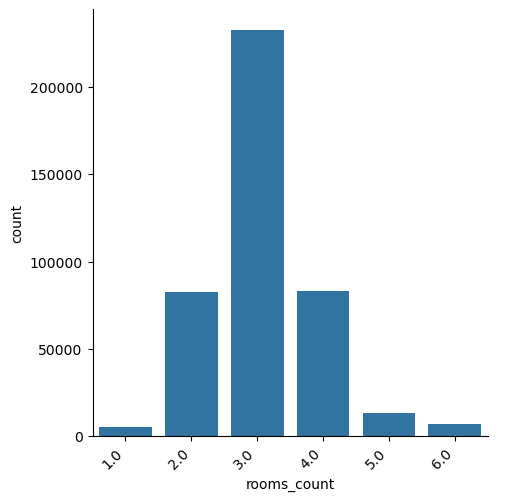

In [18]:
sns.catplot(data=df1 , x="rooms_count", kind="count")
plt.xticks(rotation=45,ha="right")
plt.show()

In [19]:
df1["price_value"]=df1["price_value"].fillna(1740030000)
df1["land_size"]=df1["land_size"].fillna(df1["building_size"])
df1["building_size"]=df1["building_size"].fillna(df1["land_size"])
df1["rooms_count"]=df1["rooms_count"].fillna(3)
df1["location_latitude"]=df1["location_latitude"].fillna(35.046600)
df1["location_longitude"]=df1["location_longitude"].fillna(51.546260)
df1 = df1.dropna(subset=["land_size"])
df1 = df1.dropna(subset=["building_size"])
df1.shape

(424442, 37)

In [20]:
df1.describe()

,price_value,land_size,building_size,floor,rooms_count,total_floors_count,unit_per_floor,location_latitude,location_longitude
count,4.244420e+05,4.244420e+05,4.244420e+05,302373.000000,424442.000000,186483.000000,184404.000000,424442.000000,424442.000000
mean,1.547958e+10,1.483944e+03,1.085004e+03,2.851442,3.087694,4.957546,2.339510,35.125567,51.563406
std,5.286585e+11,7.627807e+04,6.493766e+04,2.215483,0.841966,2.757084,1.430052,1.755553,2.433289
min,0.000000e+00,1.000000e+00,1.000000e+00,0.000000,1.000000,2.000000,1.000000,23.636976,43.774818
25%,1.720000e+09,7.700000e+01,7.500000e+01,1.000000,3.000000,4.000000,1.000000,35.046600,51.020851
50%,3.100000e+09,1.050000e+02,1.000000e+02,2.000000,3.000000,4.000000,2.000000,35.297815,51.546260
75%,6.050000e+09,1.600000e+02,1.370000e+02,4.000000,3.000000,5.000000,3.000000,35.772238,51.546260
max,1.000000e+14,1.000000e+07,1.000000e+07,30.000000,6.000000,30.000000,8.000000,40.358055,62.558594


In [21]:
df1["total_floors_count"]=df1["total_floors_count"].fillna(5)
df1["unit_per_floor"]=df1["unit_per_floor"].fillna(2)
df1["floor"]=df1["floor"].fillna(3)

In [22]:
df1.isnull().sum()

cat2_slug                  0
cat3_slug                  0
city_slug                  0
neighborhood_slug          0
user_type                  0
description                0
title                      0
price_mode                 0
price_value                0
land_size                  0
building_size              0
deed_type                  0
floor                      0
rooms_count                0
total_floors_count         0
unit_per_floor             0
has_balcony                0
has_elevator               0
has_warehouse              0
has_parking                0
construction_year          0
is_rebuilt                 0
has_water                  0
has_warm_water_provider    0
has_electricity            0
has_gas                    0
has_heating_system         0
has_cooling_system         0
has_restroom               0
has_barbecue               0
building_direction         0
has_pool                   0
has_jacuzzi                0
has_sauna                  0
floor_material

In [23]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 424442 entries, 0 to 424442
Data columns (total 37 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   cat2_slug                424442 non-null  object 
 1   cat3_slug                424442 non-null  object 
 2   city_slug                424442 non-null  object 
 3   neighborhood_slug        424442 non-null  object 
 4   user_type                424442 non-null  object 
 5   description              424442 non-null  object 
 6   title                    424442 non-null  object 
 7   price_mode               424442 non-null  object 
 8   price_value              424442 non-null  float64
 9   land_size                424442 non-null  float64
 10  building_size            424442 non-null  float64
 11  deed_type                424442 non-null  object 
 12  floor                    424442 non-null  float64
 13  rooms_count              424442 non-null  float64
 14  total_flo

In [24]:
# Save new csv file
df1.to_csv("divar_new.csv",index=False)